# Supermarket Sales — Data Cleaning & Exploratory Analysis

This notebook cleans the raw `supermarket_sales.csv` dataset and performs initial exploratory
data analysis (EDA) to prepare it for a BI dashboard (Power BI / Tableau / Looker Studio).

**Steps covered:**
1. Load & inspect raw data
2. Standardize column names
3. Remove duplicate records
4. Handle missing values
5. Fix data types (dates, numerics, categoricals)
6. Remove unnecessary / constant columns
7. Feature engineering (hour, weekday, month, weekend flag)
8. Save cleaned dataset
9. Quick EDA & KPI sanity checks


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
%matplotlib inline

## 1. Load & Inspect Raw Data

In [2]:
df = pd.read_csv("data/supermarket_sales.csv")
print(df.shape)
df.head()

(1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Invoice ID,1000,1000,750-67-8428,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Branch,1000,3,A,340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1000,3,Yangon,340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer type,1000,2,Member,501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,1000,2,Female,501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product line,1000,6,Fashion accessories,178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unit price,1000.0,NaN,NaN,NaN,55.67213,26.494628,10.08,32.875,55.23,77.935,99.96
Quantity,1000.0,NaN,NaN,NaN,5.51,2.923431,1.0,3.0,5.0,8.0,10.0
Tax 5%,1000.0,NaN,NaN,NaN,15.379369,11.708825,0.5085,5.924875,12.088,22.44525,49.65
Total,1000.0,NaN,NaN,NaN,322.966749,245.885335,10.6785,124.422375,253.848,471.35025,1042.65


## 2. Standardize Column Names

In [5]:
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("%", "pct")
)
df.columns.tolist()

['invoice_id',
 'branch',
 'city',
 'customer_type',
 'gender',
 'product_line',
 'unit_price',
 'quantity',
 'tax_5pct',
 'total',
 'date',
 'time',
 'payment',
 'cogs',
 'gross_margin_percentage',
 'gross_income',
 'rating']

## 3. Remove Duplicate Records

In [6]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows found: {dup_count}")
df = df.drop_duplicates()
print(f"Shape after dropping duplicates: {df.shape}")

Duplicate rows found: 0
Shape after dropping duplicates: (1000, 17)


## 4. Handle Missing Values

In [7]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

No missing values found.


In [8]:
# Generic handling (kept for reusability even though this dataset has no nulls)
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

if "invoice_id" in df.columns:
    df = df.dropna(subset=["invoice_id"])

print("Missing values after handling:", df.isnull().sum().sum())

Missing values after handling: 0


/tmp/ipykernel_636/1160506314.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


## 5. Fix Data Types

In [9]:
# Combine date + time into a single datetime column
df["datetime"] = pd.to_datetime(df["date"].astype(str) + " " + df["time"].astype(str), errors="coerce")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

numeric_cols = ["unit_price", "quantity", "tax_5pct", "total", "cogs", "gross_margin_percentage", "gross_income", "rating"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

cat_cols = ["branch", "city", "customer_type", "gender", "product_line", "payment"]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

df.dtypes

invoice_id                            str
branch                           category
city                             category
customer_type                    category
gender                           category
product_line                     category
unit_price                        float64
quantity                            int64
tax_5pct                          float64
total                             float64
date                       datetime64[us]
time                                  str
payment                          category
cogs                              float64
gross_margin_percentage           float64
gross_income                      float64
rating                            float64
datetime                   datetime64[us]
dtype: object

## 6. Remove Unnecessary Columns

`gross_margin_percentage` is constant across every row (4.76%) — it carries no analytical signal, so we drop it.

In [10]:
print(df["gross_margin_percentage"].unique())
df = df.drop(columns=["gross_margin_percentage"])
df.shape

[4.76190476]


(1000, 17)

## 7. Feature Engineering
Derive time-based features useful for dashboarding (hour of day, weekday, month, weekend flag).

In [11]:
df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.day_name()
df["month"] = df["datetime"].dt.month_name()
df["is_weekend"] = df["datetime"].dt.dayofweek.isin([5, 6])
df[["datetime", "hour", "day_of_week", "month", "is_weekend"]].head()

,datetime,hour,day_of_week,month,is_weekend
0,2019-01-05 13:08:00,13,Saturday,January,True
1,2019-03-08 10:29:00,10,Friday,March,False
2,2019-03-03 13:23:00,13,Sunday,March,True
3,2019-01-27 20:33:00,20,Sunday,January,True
4,2019-02-08 10:37:00,10,Friday,February,False


## 8. Outlier Check (Optional)
Visual check only — outliers are **not removed** by default since they may represent genuine large purchases.

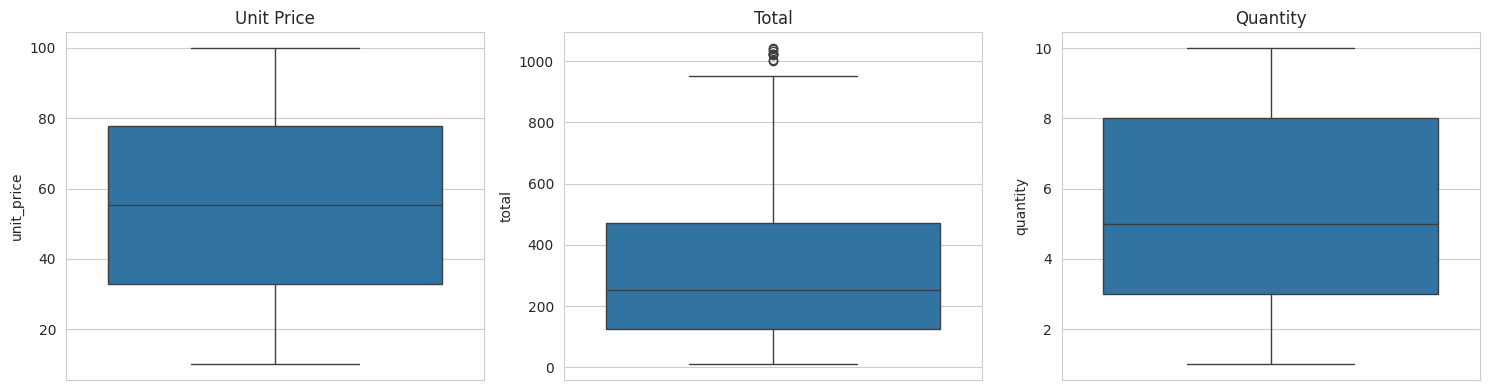

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df["unit_price"], ax=axes[0]).set_title("Unit Price")
sns.boxplot(y=df["total"], ax=axes[1]).set_title("Total")
sns.boxplot(y=df["quantity"], ax=axes[2]).set_title("Quantity")
plt.tight_layout()
plt.show()

## 9. Save Cleaned Dataset

In [13]:
df.to_csv("data/supermarket_sales_cleaned.csv", index=False)
print(f"Saved cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Saved cleaned dataset: 1000 rows, 21 columns


,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5pct,total,date,time,payment,cogs,gross_income,rating,datetime,hour,day_of_week,month,is_weekend
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08,Ewallet,522.83,26.1415,9.1,2019-01-05 13:08:00,13,Saturday,January,True
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29,Cash,76.40,3.8200,9.6,2019-03-08 10:29:00,10,Friday,March,False
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23,Credit card,324.31,16.2155,7.4,2019-03-03 13:23:00,13,Sunday,March,True
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33,Ewallet,465.76,23.2880,8.4,2019-01-27 20:33:00,20,Sunday,January,True
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37,Ewallet,604.17,30.2085,5.3,2019-02-08 10:37:00,10,Friday,February,False


## 10. Quick EDA — KPI Sanity Checks

A few quick visuals to sanity-check the KPIs before building the full dashboard.

In [14]:
kpi_summary = {
    "Total Revenue": df["total"].sum(),
    "Total Gross Income": df["gross_income"].sum(),
    "Total COGS": df["cogs"].sum(),
    "Total Transactions": df.shape[0],
    "Avg Transaction Value": df["total"].mean(),
    "Avg Rating": df["rating"].mean(),
    "Total Units Sold": df["quantity"].sum(),
}
pd.Series(kpi_summary).round(2)

Total Revenue            322966.75
Total Gross Income        15379.37
Total COGS               307587.38
Total Transactions         1000.00
Avg Transaction Value       322.97
Avg Rating                    6.97
Total Units Sold           5510.00
dtype: float64

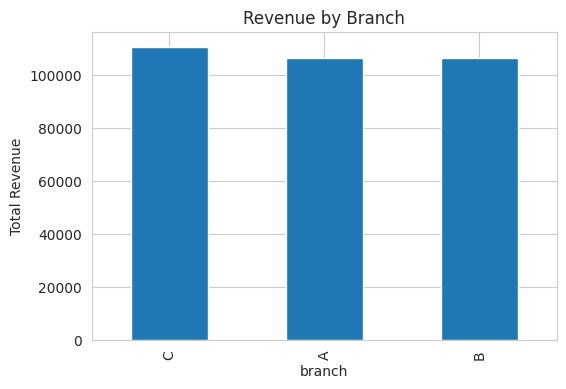

In [15]:
revenue_by_branch = df.groupby("branch")["total"].sum().sort_values(ascending=False)
revenue_by_branch.plot(kind="bar", figsize=(6,4), title="Revenue by Branch")
plt.ylabel("Total Revenue")
plt.show()

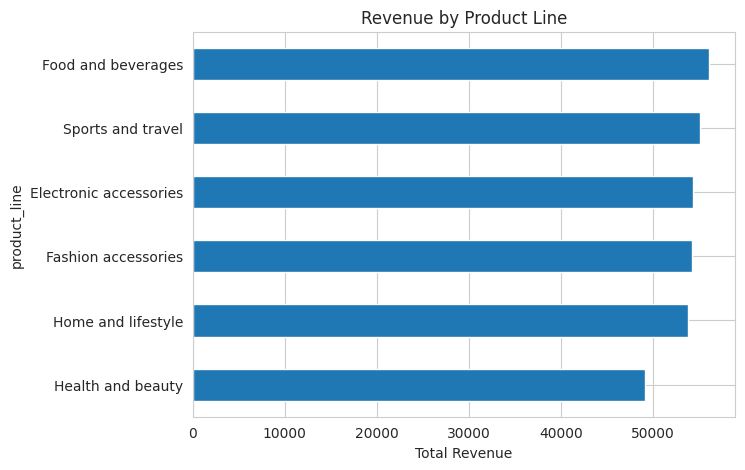

In [16]:
revenue_by_product = df.groupby("product_line")["total"].sum().sort_values()
revenue_by_product.plot(kind="barh", figsize=(7,5), title="Revenue by Product Line")
plt.xlabel("Total Revenue")
plt.show()

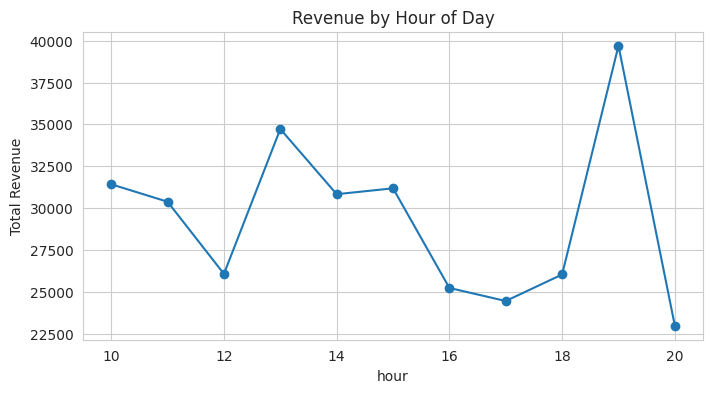

In [17]:
sales_by_hour = df.groupby("hour")["total"].sum()
sales_by_hour.plot(kind="line", marker="o", figsize=(8,4), title="Revenue by Hour of Day")
plt.ylabel("Total Revenue")
plt.show()

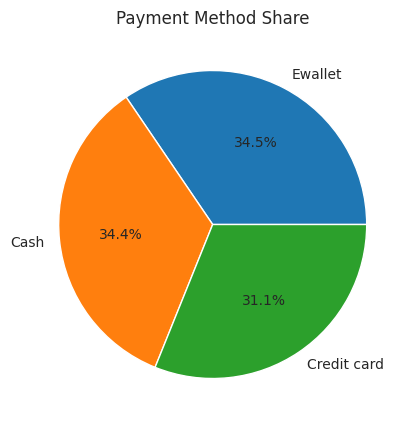

In [18]:
payment_share = df["payment"].value_counts(normalize=True) * 100
payment_share.plot(kind="pie", autopct="%1.1f%%", figsize=(5,5), title="Payment Method Share")
plt.ylabel("")
plt.show()

## Next Steps

- Load `data/supermarket_sales_cleaned.csv` into Power BI / Tableau / Looker Studio.
- Build dashboard visuals around the KPIs listed in `README.md`.
- Optionally push cleaned data to a database (Postgres/BigQuery) for a live-connected dashboard.
